## Campaign & Customer Analysis

This notebook analyzes:
- `meta_data.json` — campaigns, adsets, creatives, ads, insights
- `conversations.json` — customers, sources, outcomes
- `products.json` — loaded for completeness (not the focus)

Focus:
- Categorical data dictionary
- Simple **campaign** and **customer** visualizations
- Campaign scorecard + customer segments + cycle/time view


In [1]:
from __future__ import annotations

import json
from pathlib import Path
from collections import Counter, defaultdict

ROOT = Path('.').resolve()

paths = {
    'meta': ROOT / 'meta_data.json',
    'conversations': ROOT / 'conversations.json',
    'products': ROOT / 'products.json',
}

missing = [k for k, p in paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing expected JSON file(s): {missing}. Expected in: {ROOT}")

print('Root:', ROOT)
for k, p in paths.items():
    print(f"- {k:13s}", p.name, f"({p.stat().st_size:,} bytes)")


def load_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

meta = load_json(paths['meta'])
conversations = load_json(paths['conversations'])
products = load_json(paths['products'])

print('\nLoaded:')
print('meta keys:', list(meta.keys()))
print('conversations:', len(conversations))
print('products:', len(products))

Root: D:\DEV\6AM LLM Club\Meta campaign recommender
- meta          meta_data.json (742,188 bytes)
- conversations conversations.json (2,161,410 bytes)
- products      products.json (19,312 bytes)

Loaded:
meta keys: ['campaigns', 'adsets', 'creatives', 'ads', 'insights']
conversations: 788
products: 105


In [2]:
# Build indices (lookups)

campaigns = meta.get('campaigns', [])
adsets = meta.get('adsets', [])
creatives = meta.get('creatives', [])
ads = meta.get('ads', [])

campaign_by_id = {c.get('id'): c for c in campaigns if isinstance(c, dict) and c.get('id')}
adset_by_id = {a.get('id'): a for a in adsets if isinstance(a, dict) and a.get('id')}
creative_by_id = {c.get('id'): c for c in creatives if isinstance(c, dict) and c.get('id')}
ad_by_id = {a.get('id'): a for a in ads if isinstance(a, dict) and a.get('id')}

product_by_id = {p.get('id'): p for p in products if isinstance(p, dict) and p.get('id')}

print('Index sizes:')
print('- campaigns:', len(campaign_by_id))
print('- adsets:   ', len(adset_by_id))
print('- creatives:', len(creative_by_id))
print('- ads:      ', len(ad_by_id))
print('- products: ', len(product_by_id))

Index sizes:
- campaigns: 12
- adsets:    26
- creatives: 30
- ads:       40
- products:  105


## Categorical data dictionary

Every categorical field across `products.json`, `conversations.json`, and `meta_data.json`, with **all unique values** and counts.

IDs (`prod_*`, `conv_*`, Meta numeric IDs) are excluded — those are keys, not categories.

In [3]:
# Catalog every categorical field + unique values (with counts)
import pandas as pd

try:
    from IPython.display import display, Markdown
except ImportError:
    def display(x):
        print(x)
    def Markdown(x):
        return x


def value_counts(values) -> pd.Series:
    return pd.Series(list(values), dtype='object').value_counts(dropna=False)


def show_cats(title: str, fields: dict[str, pd.Series]):
    display(Markdown(f'### {title}'))
    for field, series in fields.items():
        n = len(series)
        display(Markdown(f'**`{field}`** — {n} unique value(s)'))
        display(series.rename('count').to_frame())


# --- products.json ---
prod_tags = []
for p in products:
    prod_tags.extend(p.get('tags') or [])

show_cats('products.json', {
    'category': value_counts(p.get('category') for p in products),
    'tags[]': value_counts(prod_tags),
})


# --- conversations.json ---
msg_dirs = []
outcome_hist = []
cust_cities = []
cust_countries = []
for c in conversations:
    for m in c.get('messages') or []:
        msg_dirs.append(m.get('direction'))
    for h in (c.get('outcome') or {}).get('status_history') or []:
        outcome_hist.append(h.get('status'))
    cust = c.get('customer') or {}
    if 'city' in cust:
        cust_cities.append(cust.get('city'))
    if 'country' in cust:
        cust_countries.append(cust.get('country'))

show_cats('conversations.json', {
    'status': value_counts(c.get('status') for c in conversations),
    'language': value_counts(c.get('language') for c in conversations),
    'cycle': value_counts(c.get('cycle') for c in conversations),
    'source.platform': value_counts((c.get('source') or {}).get('platform') for c in conversations),
    'outcome.type': value_counts((c.get('outcome') or {}).get('type') for c in conversations),
    'outcome.status_history[].status': value_counts(outcome_hist),
    'messages[].direction': value_counts(msg_dirs),
    'customer.country': value_counts(cust_countries),
    'customer.city': value_counts(cust_cities),
})


# --- meta_data.json: campaigns ---
show_cats('meta_data.json → campaigns', {
    'objective': value_counts(c.get('objective') for c in campaigns),
    'campaign_type': value_counts(c.get('campaign_type') for c in campaigns),
    'status': value_counts(c.get('status') for c in campaigns),
    'effective_status': value_counts(c.get('effective_status') for c in campaigns),
})


# --- meta_data.json: adsets (+ nested targeting) ---
tgt_countries, tgt_cities, tgt_genders = [], [], []
tgt_age_min, tgt_age_max = [], []
lal_source, lal_ratio = [], []
for a in adsets:
    t = a.get('targeting') or {}
    geo = t.get('geo_locations') or {}
    tgt_countries.extend(geo.get('countries') or [])
    for city in geo.get('cities') or []:
        tgt_cities.append(city.get('name') if isinstance(city, dict) else city)
    tgt_genders.extend(t.get('genders') or [])
    if t.get('age_min') is not None:
        tgt_age_min.append(t['age_min'])
    if t.get('age_max') is not None:
        tgt_age_max.append(t['age_max'])
    ls = t.get('lookalike_spec') or {}
    if ls.get('source') is not None:
        lal_source.append(ls['source'])
    if ls.get('ratio_percent') is not None:
        lal_ratio.append(ls['ratio_percent'])

show_cats('meta_data.json → adsets', {
    'audience_type': value_counts(a.get('audience_type') for a in adsets),
    'optimization_goal': value_counts(a.get('optimization_goal') for a in adsets),
    'billing_event': value_counts(a.get('billing_event') for a in adsets),
    'bid_strategy': value_counts(a.get('bid_strategy') for a in adsets),
    'status': value_counts(a.get('status') for a in adsets),
    'effective_status': value_counts(a.get('effective_status') for a in adsets),
    'targeting.geo_locations.countries[]': value_counts(tgt_countries),
    'targeting.geo_locations.cities[].name': value_counts(tgt_cities),
    'targeting.genders[] (1=male, 2=female)': value_counts(tgt_genders),
    'targeting.age_min': value_counts(tgt_age_min),
    'targeting.age_max': value_counts(tgt_age_max),
    'targeting.lookalike_spec.source': value_counts(lal_source),
    'targeting.lookalike_spec.ratio_percent': value_counts(lal_ratio),
})


# --- meta_data.json: creatives ---
cta_types = []
for c in creatives:
    try:
        cta_types.append(c['object_story_spec']['link_data']['call_to_action']['type'])
    except (KeyError, TypeError):
        pass

show_cats('meta_data.json → creatives', {
    'theme': value_counts(c.get('theme') for c in creatives),
    'angle': value_counts(c.get('angle') for c in creatives),
    'status': value_counts(c.get('status') for c in creatives),
    'object_story_spec.link_data.call_to_action.type': value_counts(cta_types),
})


# --- meta_data.json: ads ---
show_cats('meta_data.json → ads', {
    'status': value_counts(a.get('status') for a in ads),
    'effective_status': value_counts(a.get('effective_status') for a in ads),
})


# Summary table of all categorical fields
cat_summary_rows = []


def add_summary(entity: str, field: str, series: pd.Series):
    vals = [str(v) for v in series.index.tolist()]
    cat_summary_rows.append({
        'entity': entity,
        'field': field,
        'n_unique': len(series),
        'values': ', '.join(vals),
    })


add_summary('products', 'category', value_counts(p.get('category') for p in products))
add_summary('products', 'tags[]', value_counts(prod_tags))
add_summary('conversations', 'status', value_counts(c.get('status') for c in conversations))
add_summary('conversations', 'language', value_counts(c.get('language') for c in conversations))
add_summary('conversations', 'cycle', value_counts(c.get('cycle') for c in conversations))
add_summary('conversations', 'source.platform', value_counts((c.get('source') or {}).get('platform') for c in conversations))
add_summary('conversations', 'outcome.type', value_counts((c.get('outcome') or {}).get('type') for c in conversations))
add_summary('conversations', 'outcome.status_history[].status', value_counts(outcome_hist))
add_summary('conversations', 'messages[].direction', value_counts(msg_dirs))
add_summary('conversations', 'customer.country', value_counts(cust_countries))
add_summary('conversations', 'customer.city', value_counts(cust_cities))
add_summary('campaigns', 'objective', value_counts(c.get('objective') for c in campaigns))
add_summary('campaigns', 'campaign_type', value_counts(c.get('campaign_type') for c in campaigns))
add_summary('campaigns', 'status', value_counts(c.get('status') for c in campaigns))
add_summary('campaigns', 'effective_status', value_counts(c.get('effective_status') for c in campaigns))
add_summary('adsets', 'audience_type', value_counts(a.get('audience_type') for a in adsets))
add_summary('adsets', 'optimization_goal', value_counts(a.get('optimization_goal') for a in adsets))
add_summary('adsets', 'billing_event', value_counts(a.get('billing_event') for a in adsets))
add_summary('adsets', 'bid_strategy', value_counts(a.get('bid_strategy') for a in adsets))
add_summary('adsets', 'status', value_counts(a.get('status') for a in adsets))
add_summary('adsets', 'effective_status', value_counts(a.get('effective_status') for a in adsets))
add_summary('adsets', 'targeting.countries[]', value_counts(tgt_countries))
add_summary('adsets', 'targeting.cities[]', value_counts(tgt_cities))
add_summary('adsets', 'targeting.genders[]', value_counts(tgt_genders))
add_summary('adsets', 'targeting.age_min', value_counts(tgt_age_min))
add_summary('adsets', 'targeting.age_max', value_counts(tgt_age_max))
add_summary('adsets', 'lookalike_spec.source', value_counts(lal_source))
add_summary('adsets', 'lookalike_spec.ratio_percent', value_counts(lal_ratio))
add_summary('creatives', 'theme', value_counts(c.get('theme') for c in creatives))
add_summary('creatives', 'angle', value_counts(c.get('angle') for c in creatives))
add_summary('creatives', 'status', value_counts(c.get('status') for c in creatives))
add_summary('creatives', 'call_to_action.type', value_counts(cta_types))
add_summary('ads', 'status', value_counts(a.get('status') for a in ads))
add_summary('ads', 'effective_status', value_counts(a.get('effective_status') for a in ads))

categorical_dictionary = pd.DataFrame(cat_summary_rows)
display(Markdown('### Master categorical dictionary (all fields)'))
display(categorical_dictionary)
print(f'Total categorical fields catalogued: {len(categorical_dictionary)}')

### products.json

**`category`** — 19 unique value(s)

,count
spices,11
honey,8
bundles,8
coffee,7
sweets,7
snacks,6
rice,6
sugar,5
household_basics,5
oils,5


**`tags[]`** — 10 unique value(s)

,count
artisan,48
single_origin,19
bestseller,15
gift_friendly,14
economy,11
ramadan_special,11
organic,10
sugar_free,7
new_arrival,7
bulk_pack,7


...

**`effective_status`** — 1 unique value(s)

,count
COMPLETED,40


### Master categorical dictionary (all fields)

,entity,field,n_unique,values
0,products,category,19,"spices, honey, bundles, coffee, sweets, snacks..."
1,products,tags[],10,"artisan, single_origin, bestseller, gift_frien..."
2,conversations,status,4,"closed, active, stuck_pending, pending_handoff"
3,conversations,language,4,"ar, en, mixed, arabizi"
4,conversations,cycle,3,"2, 3, 1"
5,conversations,source.platform,3,"meta_ctwa, organic, direct"
6,conversations,outcome.type,7,"delivered, ghosted, cancelled, refunded, activ..."
7,conversations,outcome.status_history[].status,7,"pending, confirmed, processing, shipped, deliv..."
8,conversations,messages[].direction,2,"inbound, outbound"
9,conversations,customer.country,1,EG


Total categorical fields catalogued: 34


### Categorical value charts

Bar charts for the highest-cardinality / most useful category fields.

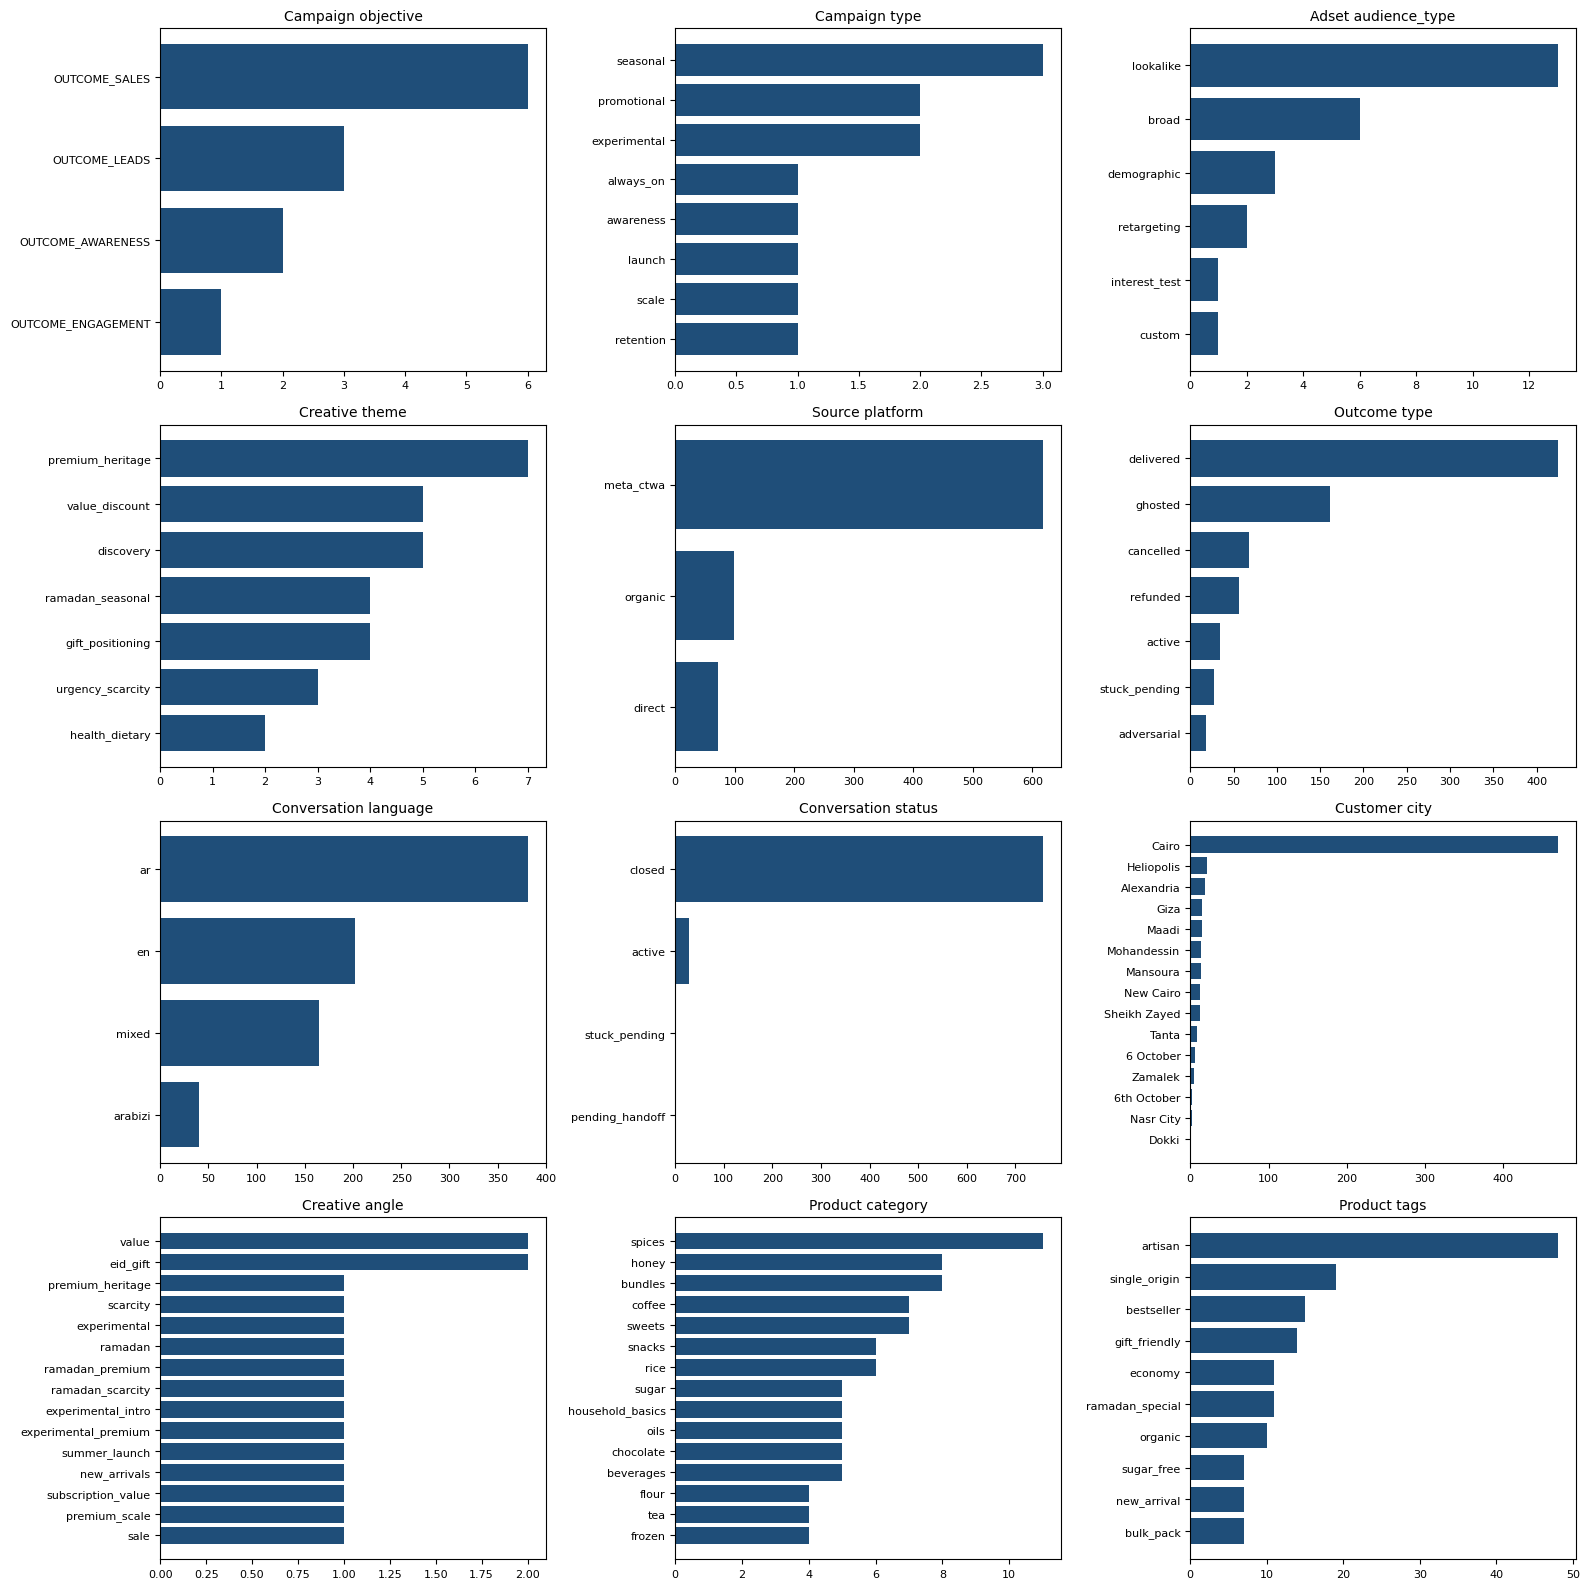

Saved categorical_dictionary.csv


,entity,field,n_unique
0,products,category,19
1,products,tags[],10
2,conversations,status,4
3,conversations,language,4
4,conversations,cycle,3
5,conversations,source.platform,3
6,conversations,outcome.type,7
7,conversations,outcome.status_history[].status,7
8,conversations,messages[].direction,2
9,conversations,customer.country,1


In [4]:
import matplotlib.pyplot as plt

chart_specs = [
    ('Campaign objective', value_counts(c.get('objective') for c in campaigns)),
    ('Campaign type', value_counts(c.get('campaign_type') for c in campaigns)),
    ('Adset audience_type', value_counts(a.get('audience_type') for a in adsets)),
    ('Creative theme', value_counts(c.get('theme') for c in creatives)),
    ('Source platform', value_counts((c.get('source') or {}).get('platform') for c in conversations)),
    ('Outcome type', value_counts((c.get('outcome') or {}).get('type') for c in conversations)),
    ('Conversation language', value_counts(c.get('language') for c in conversations)),
    ('Conversation status', value_counts(c.get('status') for c in conversations)),
    ('Customer city', value_counts(cust_cities)),
    ('Creative angle', value_counts(c.get('angle') for c in creatives)),
    ('Product category', value_counts(p.get('category') for p in products)),
    ('Product tags', value_counts(prod_tags)),
]

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.ravel()
for ax, (title, series) in zip(axes, chart_specs):
    s = series.head(15).iloc[::-1]  # top 15, horizontal bars
    ax.barh(s.index.astype(str), s.values, color='#1f4e79')
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=8)
for ax in axes[len(chart_specs):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

# Persist dictionary for later cells / export
categorical_dictionary.to_csv('categorical_dictionary.csv', index=False)
print('Saved categorical_dictionary.csv')
categorical_dictionary[['entity', 'field', 'n_unique']]

## Simple campaign & customer visualizations

Focus: **campaigns** and **customers** (not products).

Charts cover conversation volume, outcome mix, Meta spend/reach, and customer language / city / cycle.

In [5]:
# Build simple campaign + customer conversation table (1 row per conversation)

camp_rows = []
for conv in conversations:
    source = conv.get('source') or {}
    outcome = conv.get('outcome') or {}
    customer = conv.get('customer') or {}
    campaign_id = source.get('campaign_id')
    camp = campaign_by_id.get(campaign_id) if campaign_id else None
    ad = ad_by_id.get(source.get('ad_id')) if source.get('ad_id') else None
    adset = adset_by_id.get((ad or {}).get('adset_id')) if ad else None

    first_seen = customer.get('first_seen_at')
    started = conv.get('started_at')
    # returning if customer was seen before this conversation started
    is_returning = bool(first_seen and started and first_seen < started)

    camp_rows.append({
        'conversation_id': conv.get('id'),
        'platform': source.get('platform') or 'unknown',
        'campaign_id': campaign_id,
        'campaign_name': (camp or {}).get('name') or ('(organic/direct)' if not campaign_id else campaign_id),
        'campaign_type': (camp or {}).get('campaign_type'),
        'campaign_objective': (camp or {}).get('objective'),
        'audience_type': (adset or {}).get('audience_type'),
        'outcome_type': outcome.get('type') or 'no_outcome',
        'order_total': outcome.get('total'),
        'language': conv.get('language'),
        'status': conv.get('status'),
        'cycle': conv.get('cycle'),
        'customer_id': customer.get('id'),
        'city': customer.get('city') or '(unknown)',
        'country': customer.get('country'),
        'has_email': bool(customer.get('email')),
        'is_returning': is_returning,
        'started_at': started,
    })

camp_df = pd.DataFrame(camp_rows)

# Aggregate Meta insights to campaign level
insight_rows = []
for row in meta.get('insights') or []:
    insight_rows.append({
        'campaign_id': row.get('campaign_id'),
        'impressions': float(row.get('impressions') or 0),
        'reach': float(row.get('reach') or 0),
        'clicks': float(row.get('clicks') or 0),
        'link_clicks': float(row.get('link_clicks') or 0),
        'spend': float(row.get('spend') or 0),
    })
insights_df = pd.DataFrame(insight_rows)
camp_insights = (
    insights_df.groupby('campaign_id', as_index=False)
    .agg(impressions=('impressions', 'sum'), reach=('reach', 'sum'),
         clicks=('clicks', 'sum'), link_clicks=('link_clicks', 'sum'), spend=('spend', 'sum'))
)
camp_insights['campaign_name'] = camp_insights['campaign_id'].map(
    lambda cid: (campaign_by_id.get(cid) or {}).get('name', cid)
)
camp_insights['ctr'] = camp_insights['clicks'] / camp_insights['impressions'].replace(0, pd.NA) * 100
camp_insights['cpm'] = camp_insights['spend'] / camp_insights['impressions'].replace(0, pd.NA) * 1000

# Conversations + delivered revenue per campaign
attributed = camp_df.dropna(subset=['campaign_id']).copy()
conv_by_camp = attributed.groupby(['campaign_id', 'campaign_name'], as_index=False).agg(
    conversations=('conversation_id', 'nunique'),
    customers=('customer_id', 'nunique'),
    delivered=('outcome_type', lambda s: int((s == 'delivered').sum())),
    cancelled=('outcome_type', lambda s: int((s == 'cancelled').sum())),
    ghosted=('outcome_type', lambda s: int((s == 'ghosted').sum())),
)
rev = (
    attributed.query("outcome_type == 'delivered'")
    .groupby(['campaign_id', 'campaign_name'], as_index=False)['order_total']
    .sum()
    .rename(columns={'order_total': 'revenue'})
)
conv_by_camp = conv_by_camp.merge(rev, on=['campaign_id', 'campaign_name'], how='left')

camp_perf = camp_insights.merge(conv_by_camp, on=['campaign_id', 'campaign_name'], how='left').fillna({
    'conversations': 0, 'customers': 0, 'delivered': 0, 'cancelled': 0, 'ghosted': 0, 'revenue': 0,
})
camp_perf['cost_per_conversation'] = camp_perf['spend'] / camp_perf['conversations'].replace(0, pd.NA)
camp_perf['delivery_rate'] = camp_perf['delivered'] / camp_perf['conversations'].replace(0, pd.NA)

print('Conversations:', len(camp_df))
print('Unique customers:', camp_df['customer_id'].nunique())
print('Campaigns with Meta insights:', len(camp_perf))
camp_perf.sort_values('conversations', ascending=False)[
    ['campaign_name', 'spend', 'conversations', 'customers', 'delivered', 'delivery_rate', 'cost_per_conversation', 'revenue']
].round(2)

Conversations: 788
Unique customers: 643
Campaigns with Meta insights: 12


,campaign_name,spend,conversations,customers,delivered,delivery_rate,cost_per_conversation,revenue
0,Always-On Premium Acquisition,140783.91,111,109,52,0.47,1268.32,63494.0
8,Summer Premium Launch,68595.84,97,96,64,0.66,707.17,69558.0
5,Ramadan Iftar Premium Bundles,57095.26,84,84,42,0.50,679.71,74357.0
4,Ramadan Suhoor Specials,32293.38,64,64,41,0.64,504.58,37313.0
7,Post-Eid Lookalike Test,7762.12,63,63,27,0.43,123.21,41433.0
6,Eid Gifting Premium,14976.24,47,47,28,0.60,318.64,62576.0
2,Pre-Ramadan Bundle Promo,13958.72,46,46,21,0.46,303.45,25730.0
9,Lookalike Scale Cycle 3,31465.87,36,36,23,0.64,874.05,37612.0
10,Mid-Year Sale,17552.49,34,34,20,0.59,516.25,16358.0
11,Summer Retention Push,9006.65,16,16,7,0.44,562.92,4722.0


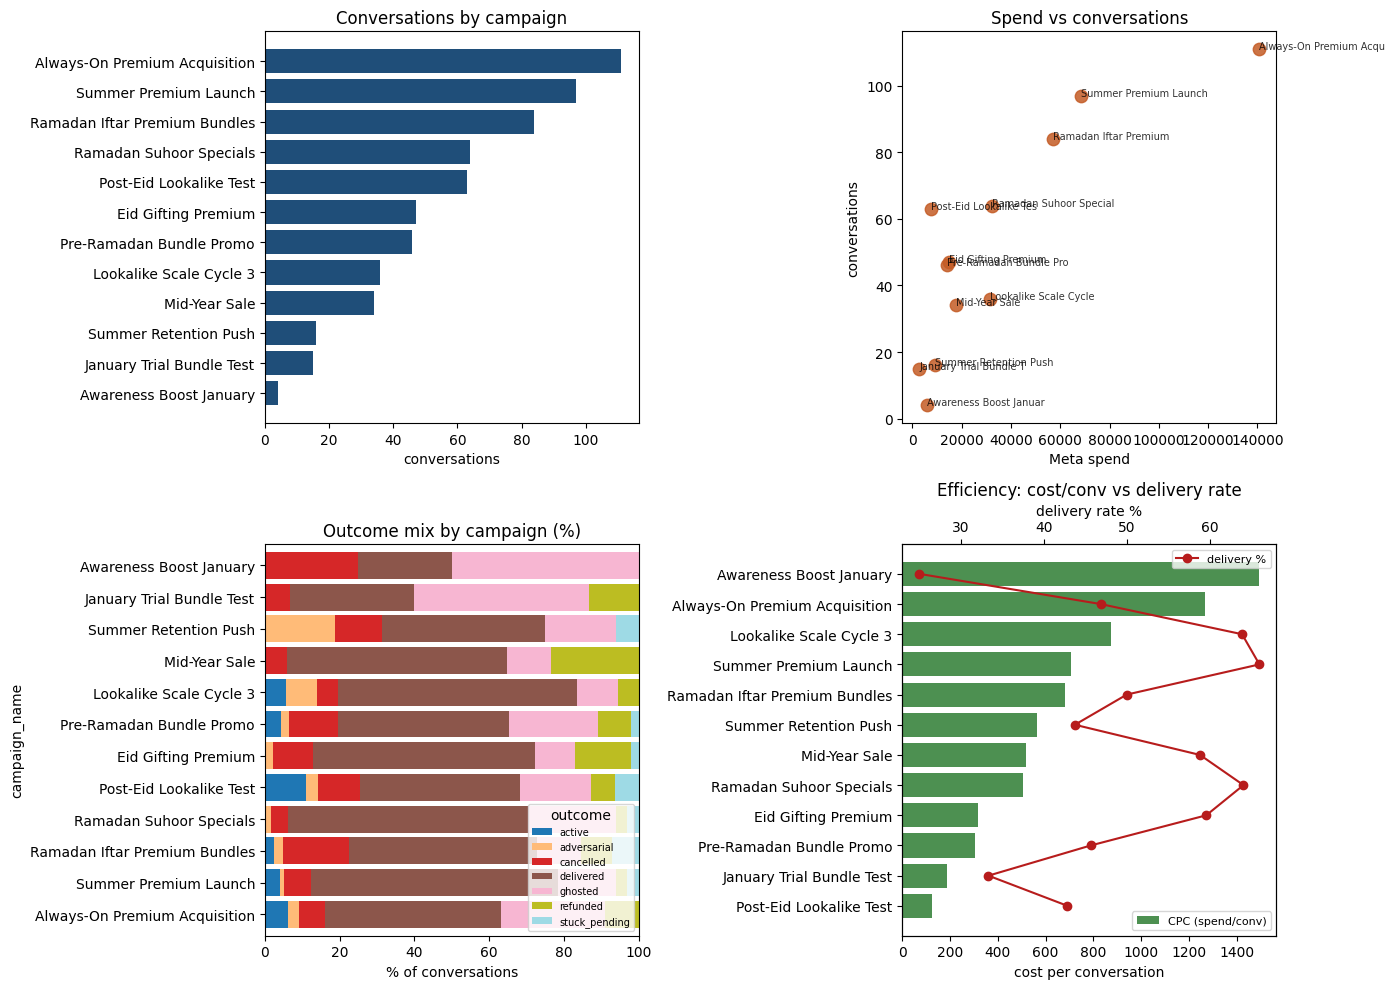

In [6]:
# --- Simple campaign charts ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Conversations by campaign
ax = axes[0, 0]
s = camp_perf.sort_values('conversations', ascending=True)
ax.barh(s['campaign_name'], s['conversations'], color='#1f4e79')
ax.set_title('Conversations by campaign')
ax.set_xlabel('conversations')

# 2) Spend vs conversations
ax = axes[0, 1]
ax.scatter(camp_perf['spend'], camp_perf['conversations'], s=80, c='#c45c26', alpha=0.85)
for _, r in camp_perf.iterrows():
    ax.annotate(r['campaign_name'][:22], (r['spend'], r['conversations']), fontsize=7, alpha=0.8)
ax.set_xlabel('Meta spend')
ax.set_ylabel('conversations')
ax.set_title('Spend vs conversations')

# 3) Outcome mix by campaign (stacked %)
ax = axes[1, 0]
outcome_mix = (
    attributed.groupby(['campaign_name', 'outcome_type']).size()
    .unstack(fill_value=0)
)
outcome_pct = outcome_mix.div(outcome_mix.sum(axis=1), axis=0) * 100
# order campaigns by volume
order = attributed.groupby('campaign_name').size().sort_values(ascending=False).index
outcome_pct = outcome_pct.loc[order]
outcome_pct.plot(kind='barh', stacked=True, ax=ax, colormap='tab20', width=0.85)
ax.set_title('Outcome mix by campaign (%)')
ax.set_xlabel('% of conversations')
ax.legend(loc='lower right', fontsize=7, title='outcome')

# 4) Cost per conversation + delivery rate
ax = axes[1, 1]
s = camp_perf.dropna(subset=['cost_per_conversation']).sort_values('cost_per_conversation', ascending=True)
ax.barh(s['campaign_name'], s['cost_per_conversation'], color='#2e7d32', alpha=0.85, label='CPC (spend/conv)')
ax2 = ax.twiny()
ax2.plot(s['delivery_rate'] * 100, s['campaign_name'], 'o-', color='#b71c1c', label='delivery %')
ax.set_xlabel('cost per conversation')
ax2.set_xlabel('delivery rate %')
ax.set_title('Efficiency: cost/conv vs delivery rate')
ax.legend(loc='lower right', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

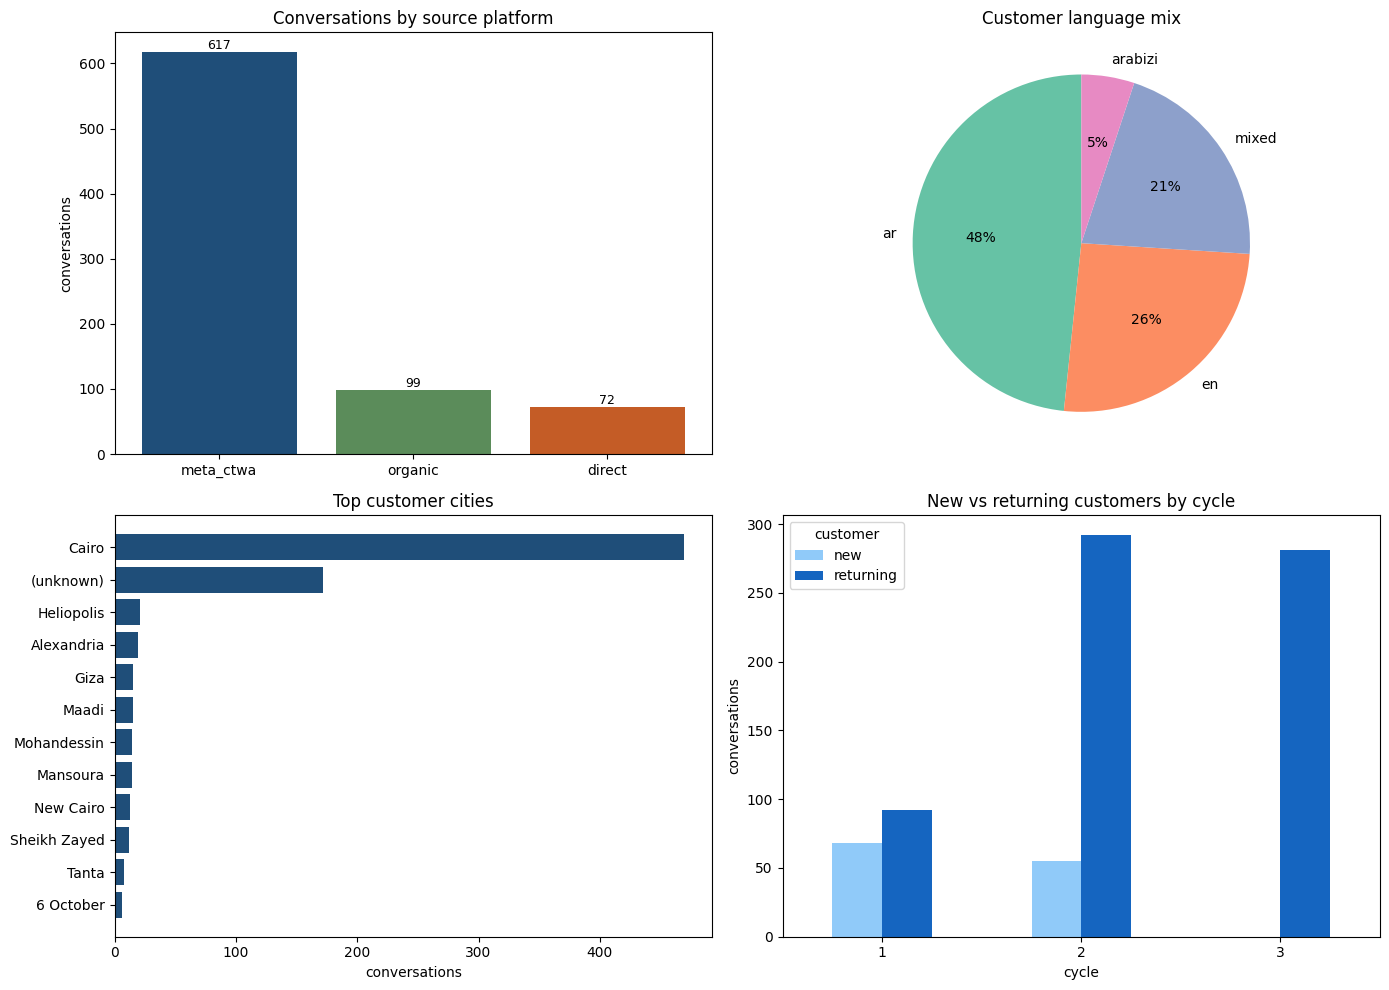

Returning share: 84.4%
Customers with email: 61.9%
Unique customers: 643 | conversations: 788 | avg convs/customer: 1.23


In [7]:
# --- Simple customer charts ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Platform mix
ax = axes[0, 0]
plat = camp_df['platform'].value_counts()
ax.bar(plat.index.astype(str), plat.values, color=['#1f4e79', '#5b8c5a', '#c45c26'][:len(plat)])
ax.set_title('Conversations by source platform')
ax.set_ylabel('conversations')
for i, v in enumerate(plat.values):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=9)

# 2) Language mix
ax = axes[0, 1]
lang = camp_df['language'].value_counts()
ax.pie(lang.values, labels=lang.index.astype(str), autopct='%1.0f%%',
       colors=plt.cm.Set2.colors[:len(lang)], startangle=90)
ax.set_title('Customer language mix')

# 3) Top cities
ax = axes[1, 0]
cities = camp_df['city'].value_counts().head(12).iloc[::-1]
ax.barh(cities.index.astype(str), cities.values, color='#1f4e79')
ax.set_title('Top customer cities')
ax.set_xlabel('conversations')

# 4) New vs returning + cycle
ax = axes[1, 1]
ret = camp_df.groupby(['cycle', 'is_returning']).size().unstack(fill_value=0)
ret.columns = ['new' if c is False else 'returning' for c in ret.columns]
ret.plot(kind='bar', ax=ax, color=['#90caf9', '#1565c0'], rot=0)
ax.set_title('New vs returning customers by cycle')
ax.set_xlabel('cycle')
ax.set_ylabel('conversations')
ax.legend(title='customer')

plt.tight_layout()
plt.show()

print('Returning share: {:.1%}'.format(camp_df['is_returning'].mean()))
print('Customers with email: {:.1%}'.format(camp_df['has_email'].mean()))
print('Unique customers:', camp_df['customer_id'].nunique(),
      '| conversations:', len(camp_df),
      '| avg convs/customer: {:.2f}'.format(len(camp_df) / camp_df['customer_id'].nunique()))

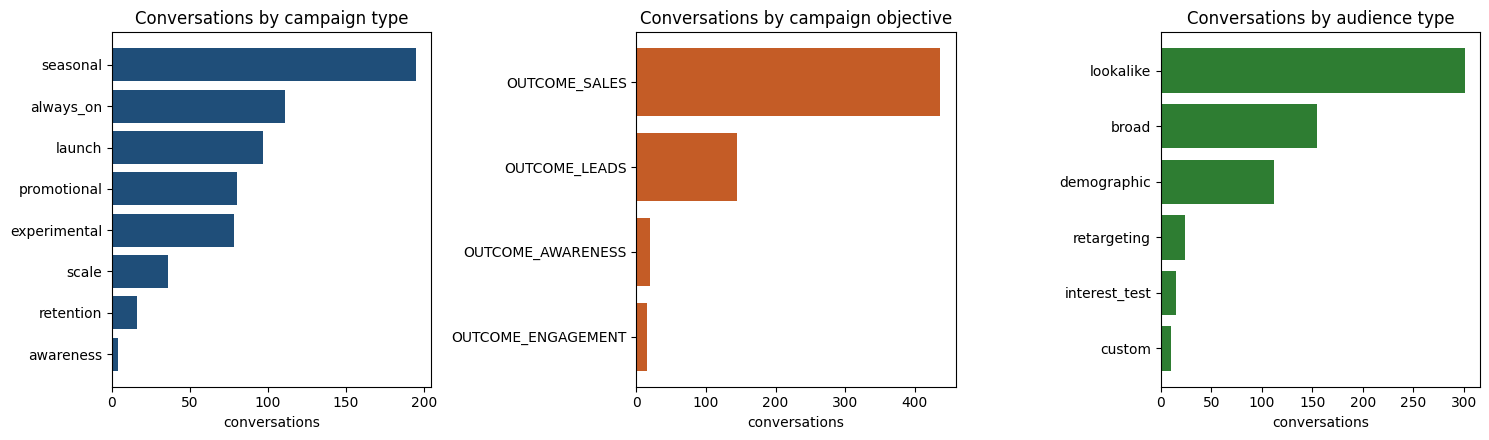

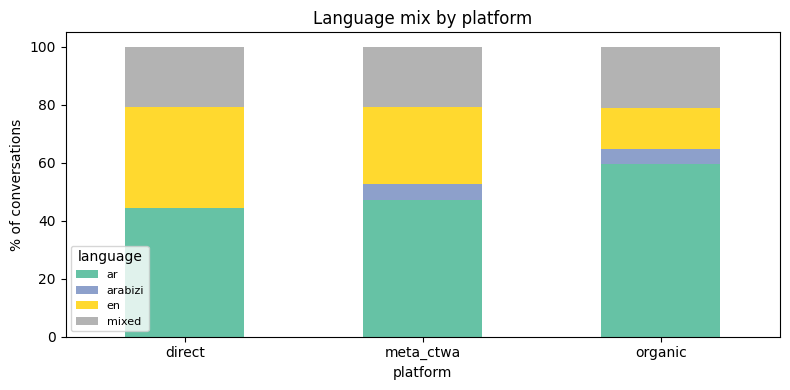

,campaign_name,impressions,reach,spend,ctr,conversations,customers,delivered,delivery_rate,cost_per_conversation,revenue
0,Always-On Premium Acquisition,26091014.0,10169030.0,140783.91,0.83,111,109,52,0.47,1268.32,63494.0
8,Summer Premium Launch,14187459.0,8308450.0,68595.84,1.26,97,96,64,0.66,707.17,69558.0
5,Ramadan Iftar Premium Bundles,8339290.0,6454402.0,57095.26,1.62,84,84,42,0.50,679.71,74357.0
4,Ramadan Suhoor Specials,4601950.0,4038656.0,32293.38,1.95,64,64,41,0.64,504.58,37313.0
7,Post-Eid Lookalike Test,1863544.0,1205985.0,7762.12,1.19,63,63,27,0.43,123.21,41433.0
6,Eid Gifting Premium,2967717.0,2598221.0,14976.24,1.61,47,47,28,0.60,318.64,62576.0
2,Pre-Ramadan Bundle Promo,2872008.0,2042872.0,13958.72,1.47,46,46,21,0.46,303.45,25730.0
9,Lookalike Scale Cycle 3,6206354.0,3455890.0,31465.87,1.24,36,36,23,0.64,874.05,37612.0
10,Mid-Year Sale,3378126.0,2539115.0,17552.49,1.60,34,34,20,0.59,516.25,16358.0
11,Summer Retention Push,1806267.0,1183345.0,9006.65,1.35,16,16,7,0.44,562.92,4722.0


In [8]:
# --- Campaign type / objective + who they bring ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Conversations by campaign_type (attributed only)
ax = axes[0]
ct = attributed['campaign_type'].value_counts().iloc[::-1]
ax.barh(ct.index.astype(str), ct.values, color='#1f4e79')
ax.set_title('Conversations by campaign type')
ax.set_xlabel('conversations')

# Conversations by objective
ax = axes[1]
ob = attributed['campaign_objective'].value_counts().iloc[::-1]
ax.barh(ob.index.astype(str), ob.values, color='#c45c26')
ax.set_title('Conversations by campaign objective')
ax.set_xlabel('conversations')

# Audience type mix
ax = axes[2]
au = attributed['audience_type'].fillna('(unknown)').value_counts().iloc[::-1]
ax.barh(au.index.astype(str), au.values, color='#2e7d32')
ax.set_title('Conversations by audience type')
ax.set_xlabel('conversations')

plt.tight_layout()
plt.show()

# Language × platform (who comes from ads vs organic)
lang_plat = camp_df.groupby(['platform', 'language']).size().unstack(fill_value=0)
lang_plat_pct = lang_plat.div(lang_plat.sum(axis=1), axis=0) * 100
ax = lang_plat_pct.plot(kind='bar', stacked=True, figsize=(8, 4), colormap='Set2', rot=0)
ax.set_title('Language mix by platform')
ax.set_ylabel('% of conversations')
ax.legend(title='language', fontsize=8)
plt.tight_layout()
plt.show()

display(camp_perf.sort_values('conversations', ascending=False)[
    ['campaign_name', 'impressions', 'reach', 'spend', 'ctr', 'conversations',
     'customers', 'delivered', 'delivery_rate', 'cost_per_conversation', 'revenue']
].round(2))

## Campaign scorecard

Ranks attributed campaigns by a simple efficiency score:
- higher **delivery rate** is better
- lower **cost per conversation** is better

Also prints plain-English scale / review / pause suggestions.


In [ ]:
# Campaign scorecard: rank by delivery rate + cost efficiency

sc = camp_perf.copy()
sc = sc[sc['conversations'] > 0].copy()

# Normalize metrics 0-1 within this set
def minmax(s):
    s = s.astype(float)
    lo, hi = s.min(), s.max()
    if pd.isna(lo) or hi == lo:
        return pd.Series([0.5] * len(s), index=s.index)
    return (s - lo) / (hi - lo)

sc['delivery_score'] = minmax(sc['delivery_rate'].fillna(0))
# invert cost: cheaper = higher score
cpc = sc['cost_per_conversation']
sc['cost_score'] = 1 - minmax(cpc.fillna(cpc.max()))
sc['volume_score'] = minmax(sc['conversations'])

# Weighted score: delivery matters most, then cost, then volume
sc['score'] = (
    0.50 * sc['delivery_score']
    + 0.35 * sc['cost_score']
    + 0.15 * sc['volume_score']
)

sc = sc.sort_values('score', ascending=False).reset_index(drop=True)
sc['rank'] = sc.index + 1

# Simple action labels by tertile of score
n = len(sc)
def action(rank):
    if rank <= max(1, n // 3):
        return 'SCALE'
    if rank <= max(2, 2 * n // 3):
        return 'REVIEW'
    return 'PAUSE/FIX'

sc['action'] = sc['rank'].map(action)

scorecard = sc[[
    'rank', 'action', 'campaign_name', 'score',
    'conversations', 'customers', 'delivered', 'delivery_rate',
    'spend', 'cost_per_conversation', 'revenue', 'ctr'
]].round({
    'score': 3,
    'delivery_rate': 3,
    'spend': 2,
    'cost_per_conversation': 2,
    'revenue': 2,
    'ctr': 2,
})

display(Markdown('### Ranked campaign scorecard'))
display(scorecard)

print('\nSuggestions:')
for _, r in scorecard.iterrows():
    print(
        f"- [{r['action']}] {r['campaign_name']}: "
        f"{int(r['conversations'])} convs, "
        f"delivery {r['delivery_rate']:.0%}, "
        f"cost/conv {r['cost_per_conversation']:.0f}"
    )

# Visual scorecard
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'SCALE': '#2e7d32', 'REVIEW': '#f9a825', 'PAUSE/FIX': '#c62828'}
y = scorecard.sort_values('score')
ax.barh(y['campaign_name'], y['score'], color=[colors[a] for a in y['action']])
ax.set_xlabel('score (0-1)')
ax.set_title('Campaign scorecard (delivery + cost efficiency + volume)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=k) for k, c in colors.items()], loc='lower right')
plt.tight_layout()
plt.show()


## Customer segments (who converts?)

Delivery rate by language, city, platform, and new vs returning — no products.


In [ ]:
# Customer segment delivery rates

def segment_delivery(df, col, min_n=15, top_n=12):
    g = (
        df.groupby(col)
        .agg(
            conversations=('conversation_id', 'nunique'),
            customers=('customer_id', 'nunique'),
            delivered=('outcome_type', lambda s: int((s == 'delivered').sum())),
        )
        .reset_index()
    )
    g['delivery_rate'] = g['delivered'] / g['conversations'].replace(0, pd.NA)
    g = g[g['conversations'] >= min_n].sort_values('delivery_rate', ascending=False)
    return g.head(top_n)

seg_lang = segment_delivery(camp_df, 'language', min_n=10)
seg_plat = segment_delivery(camp_df, 'platform', min_n=10)
seg_city = segment_delivery(camp_df, 'city', min_n=10)
camp_df = camp_df.copy()
camp_df['customer_type'] = camp_df['is_returning'].map({True: 'returning', False: 'new'})
seg_ret = segment_delivery(camp_df, 'customer_type', min_n=10)

display(Markdown('### Delivery rate by language'))
display(seg_lang.round({'delivery_rate': 3}))
display(Markdown('### Delivery rate by platform'))
display(seg_plat.round({'delivery_rate': 3}))
display(Markdown('### Delivery rate by city (min 10 conversations)'))
display(seg_city.round({'delivery_rate': 3}))
display(Markdown('### Delivery rate: new vs returning'))
display(seg_ret.round({'delivery_rate': 3}))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

def plot_seg(ax, seg, col, title):
    s = seg.sort_values('delivery_rate')
    ax.barh(s[col].astype(str), s['delivery_rate'] * 100, color='#1f4e79')
    ax.set_xlabel('delivery rate %')
    ax.set_title(title)
    for i, (_, r) in enumerate(s.iterrows()):
        ax.text(r['delivery_rate'] * 100 + 0.5, i, f"n={int(r['conversations'])}", va='center', fontsize=8)

plot_seg(axes[0, 0], seg_lang, 'language', 'Delivery rate by language')
plot_seg(axes[0, 1], seg_plat, 'platform', 'Delivery rate by platform')
plot_seg(axes[1, 0], seg_city, 'city', 'Delivery rate by city')
plot_seg(axes[1, 1], seg_ret, 'customer_type', 'Delivery rate: new vs returning')
plt.tight_layout()
plt.show()


## Cycle & time view

How volume and delivery change across cycles and months.


In [ ]:
# Cycle + monthly volume / delivery

camp_df['started_at'] = pd.to_datetime(camp_df['started_at'], errors='coerce', utc=True)
camp_df['month'] = camp_df['started_at'].dt.tz_convert(None).dt.to_period('M').astype(str)

cycle_stats = (
    camp_df.groupby('cycle')
    .agg(
        conversations=('conversation_id', 'nunique'),
        customers=('customer_id', 'nunique'),
        delivered=('outcome_type', lambda s: int((s == 'delivered').sum())),
    )
    .reset_index()
)
cycle_stats['delivery_rate'] = cycle_stats['delivered'] / cycle_stats['conversations']

month_stats = (
    camp_df.dropna(subset=['month'])
    .groupby('month')
    .agg(
        conversations=('conversation_id', 'nunique'),
        delivered=('outcome_type', lambda s: int((s == 'delivered').sum())),
    )
    .reset_index()
    .sort_values('month')
)
month_stats['delivery_rate'] = month_stats['delivered'] / month_stats['conversations']

# Attributed campaign mix by cycle
cycle_camp = (
    attributed.groupby(['cycle', 'campaign_name']).size()
    .reset_index(name='conversations')
)

display(Markdown('### By cycle'))
display(cycle_stats.round({'delivery_rate': 3}))
display(Markdown('### By month'))
display(month_stats.round({'delivery_rate': 3}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.bar(cycle_stats['cycle'].astype(str), cycle_stats['conversations'], color='#1f4e79', label='conversations')
ax2 = ax.twinx()
ax2.plot(cycle_stats['cycle'].astype(str), cycle_stats['delivery_rate'] * 100, 'o-', color='#c62828', label='delivery %')
ax.set_title('Conversations & delivery by cycle')
ax.set_xlabel('cycle')
ax.set_ylabel('conversations')
ax2.set_ylabel('delivery rate %')

ax = axes[1]
ax.plot(month_stats['month'], month_stats['conversations'], 'o-', color='#1f4e79', label='conversations')
ax2 = ax.twinx()
ax2.plot(month_stats['month'], month_stats['delivery_rate'] * 100, 's--', color='#c62828', label='delivery %')
ax.set_title('Monthly volume & delivery')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.set_ylabel('conversations')
ax2.set_ylabel('delivery rate %')

ax = axes[2]
# top campaigns contribution by cycle (stacked)
top_names = attributed['campaign_name'].value_counts().head(6).index
pivot = (
    attributed[attributed['campaign_name'].isin(top_names)]
    .groupby(['cycle', 'campaign_name']).size()
    .unstack(fill_value=0)
)
pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', rot=0)
ax.set_title('Top campaigns by cycle')
ax.set_xlabel('cycle')
ax.set_ylabel('conversations')
ax.legend(fontsize=7, loc='best')

plt.tight_layout()
plt.show()


## Recommender goal (v1)

Suggested v1 output (campaign + customer only):

> **Recommend the next Meta campaign setup** — campaign type, objective, and audience —  
> for a target customer segment (language / city / new vs returning),  
> optimized for **delivery rate** and **cost per conversation**.

Products stay out of v1 on purpose.
